![Employee Attrition](../Documents/employee_attrition.jpg)

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
<b>1️⃣ Problem Statement</b><br><br>
Employee attrition is a major challenge for organizations, leading to increased recruitment costs
and loss of skilled talent. Predicting whether an employee is likely to look for a job change
helps organizations proactively design effective retention strategies.
</div>


<div style="background:#e7f3ff; padding:12px; border-left:5px solid #1e90ff; color:#000;">
<b>2️⃣ Objectives</b>
<ul>
<li>Predict whether an employee is looking for a job change</li>
<li>Identify key factors influencing job change decisions</li>
<li>Compare multiple machine learning models and select the best one</li>
</ul>
</div>

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
<b>3️⃣ Target Variable</b>
<ul>
<li><b>0</b> → Not looking for a job change</li>
<li><b>1</b> → Looking for a job change</li>
</ul>
</div>

<div style="background:#e7f3ff; padding:12px; border-left:5px solid #1e90ff; color:#000;">
<b>4️⃣ Project Flow (Tools & Techniques)</b>
<ol>
<li>Data Loading</li>
<li>Exploratory Data Analysis (EDA)</li>
<li>Data Cleaning & Preprocessing</li>
<li>Feature Encoding</li>
<li>Model Building</li>
<li>Model Evaluation</li>
<li>Model Comparison</li>
<li>Business Insights</li>
</ol>
</div>

## 🟢 Let’s Start

In [114]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

In [115]:
#LOAD DATA
train = pd.read_csv("aug_train.csv")
test = pd.read_csv("aug_test.csv")

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
We load training and testing datasets to build and validate our model.
</div>

In [116]:
{"Train shape": train.shape, "Test shape": test.shape}

{'Train shape': (19158, 14), 'Test shape': (2129, 13)}

In [117]:
train.head(8)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1.0
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0.0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0


In [118]:
#Data Understanding
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
The dataset contains missing values and categorical features which require preprocessing.
</div>

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
#We do not use the test dataset for data understanding or EDA because it can cause data leakage and biased model evaluation.


#Training data = past experience.   
#Test data = future employees.

#We cannot study future employees before making predictions.
</div>

In [119]:
#CHECK MISSING VALUES
train.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [120]:
#HANDLE MISSING VALUES
for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].fillna(train[col].mode().iloc[0])
    else:
        train[col] = train[col].fillna(train[col].median())

#Categorical → mode
#Numerical → median       

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
Missing categorical values are filled using mode, numerical values using median.
</div>

In [121]:
#ENCODE CATEGORICAL VARIABLES
for col in train.select_dtypes(include='object'):
    train[col] = LabelEncoder().fit_transform(train[col])

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
Machine learning models require numeric inputs, so categorical variables are encoded.
</div>


Text(0.5, 1.0, 'Job Change Distribution')

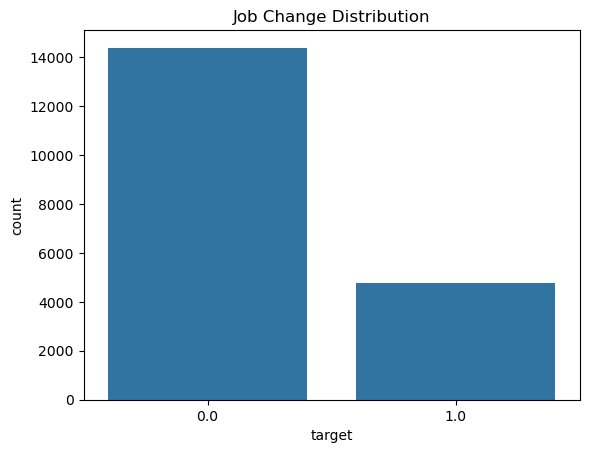

In [122]:
#EXPLORATORY DATA ANALYSIS (EDA)

#Target Distribution
sns.countplot(x='target', data=train)
plt.title("Job Change Distribution")

Text(0.5, 1.0, 'Training Hours vs Job Change')

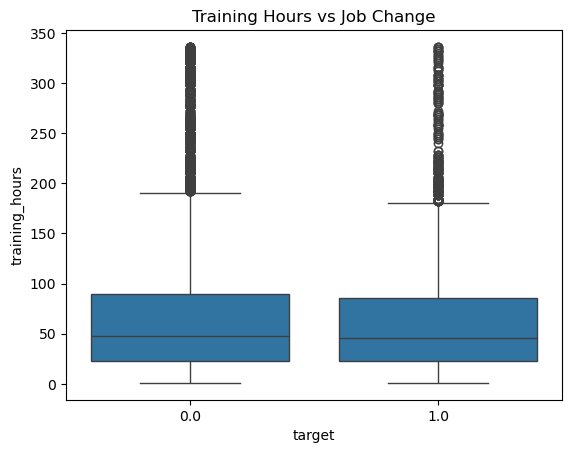

In [123]:
#Training Hours vs Job Change
sns.boxplot(x='target', y='training_hours', data=train)
plt.title("Training Hours vs Job Change")

Text(0.5, 1.0, 'City Development Index vs Job Change')

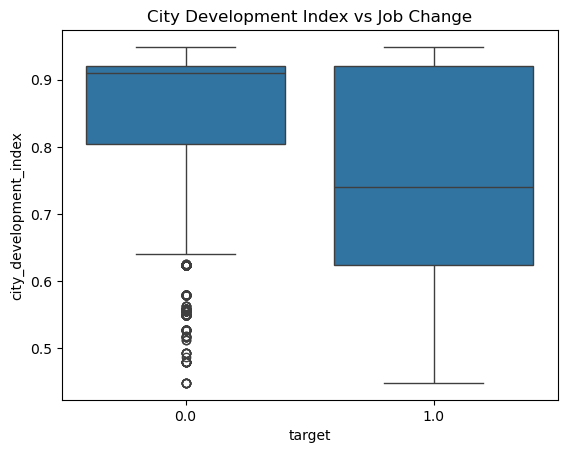

In [124]:
#City Development Index vs Job Change
sns.boxplot(x='target', y='city_development_index', data=train)
plt.title("City Development Index vs Job Change")

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
EDA is used to understand the distribution of the target variable and examine how features like training hours and city development index relate to employees’ likelihood of job change.
</div>

In [125]:
#FEATURE SELECTION
X = train.drop(columns=['target', 'enrollee_id'])
y = train['target']

In [126]:
#TRAIN–TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [127]:
#MODEL 1: RANDOM FOREST
rf_model = RandomForestClassifier(n_estimators=200,random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [128]:
#EVALUATE RANDOM FOREST
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7667014613778705
              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85      2880
         1.0       0.54      0.42      0.47       952

    accuracy                           0.77      3832
   macro avg       0.68      0.65      0.66      3832
weighted avg       0.75      0.77      0.76      3832



<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
We train a Random Forest classifier on the training data to predict employee job change.
The model’s performance is evaluated on the test set using accuracy and a classification report to assess prediction quality.
</div>

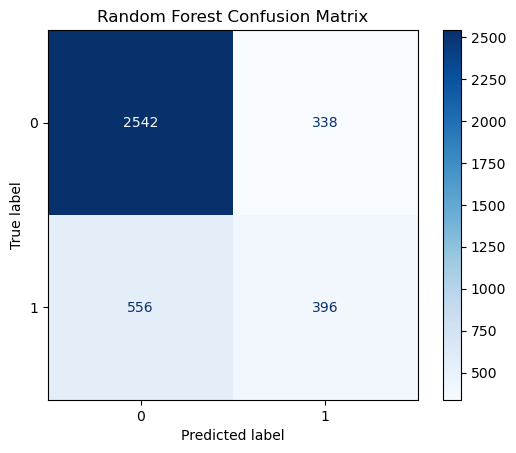

In [129]:
#CONFUSION MATRIX
rf_cm = confusion_matrix(y_test, rf_pred)
ConfusionMatrixDisplay(rf_cm).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [130]:
# PRECISION, RECALLl, F1
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.88      0.85      2880
         1.0       0.54      0.42      0.47       952

    accuracy                           0.77      3832
   macro avg       0.68      0.65      0.66      3832
weighted avg       0.75      0.77      0.76      3832



In [131]:
#MODEL 2: GRADIENT BOOSTING
gb_model = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [132]:
#EVALUATE GRADIENT BOOSTING
gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy: 0.7771398747390397
              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86      2880
         1.0       0.57      0.42      0.48       952

    accuracy                           0.78      3832
   macro avg       0.70      0.66      0.67      3832
weighted avg       0.76      0.78      0.77      3832



<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
We train a Gradient Boosting classifier on the training data to predict employee job change.
The model’s performance is evaluated on the test set using accuracy and a classification report.
</div>

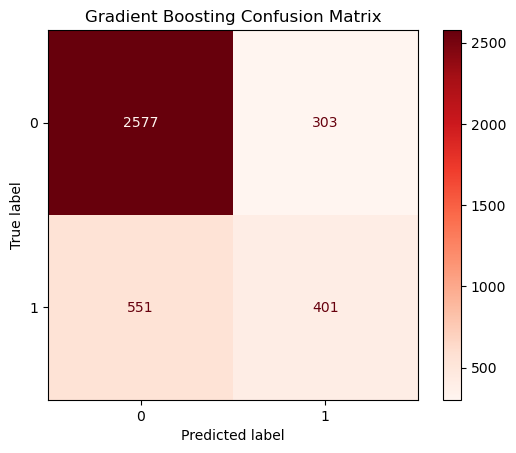

In [133]:
#CONFUSION MATRIX
gb_cm = confusion_matrix(y_test, gb_pred)
ConfusionMatrixDisplay(gb_cm).plot(cmap="Reds")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

In [134]:
#PRECISION, RECALL, F1
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

         0.0       0.82      0.89      0.86      2880
         1.0       0.57      0.42      0.48       952

    accuracy                           0.78      3832
   macro avg       0.70      0.66      0.67      3832
weighted avg       0.76      0.78      0.77      3832



In [135]:
#MODEL 3: LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [136]:
#EVALUATE LOGISTIC REGRESSION
lr_pred = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.7656576200417536
              precision    recall  f1-score   support

         0.0       0.79      0.94      0.86      2880
         1.0       0.56      0.25      0.35       952

    accuracy                           0.77      3832
   macro avg       0.68      0.59      0.60      3832
weighted avg       0.73      0.77      0.73      3832



<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
We train a Logistic Regression classifier on the training data to predict employee job change. The model’s performance is evaluated on the test set using accuracy and a classification report.</div>

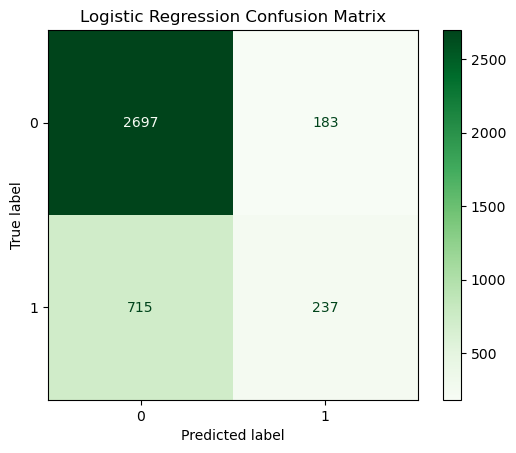

In [137]:
#CONFUSION MATRIX — LOGISTIC REGRESSION
lr_cm = confusion_matrix(y_test, lr_pred)
ConfusionMatrixDisplay(lr_cm).plot(cmap="Greens")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
Confusion Matrix shows how many predictions are correct and incorrect by comparing actual vs predicted classes in a table format.
</div>

<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
Precision measures how many of the employees predicted to leave were actually leaving (focus on false positives).</div>
<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">    
Recall measures how many of the actual leaving employees were correctly identified by the model (focus on false negatives).</div>
<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">     
F1 Score is the harmonic mean of Precision and Recall, giving a balanced measure of model performance for imbalanced data.</div>

In [138]:
#MODEL COMPARISON
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, lr_pred)]
})

comparison

,Model,Accuracy
0,Random Forest,0.766701
1,Gradient Boosting,0.777140
2,Logistic Regression,0.765658


<div style="background:#fff3cd; padding:12px; border-left:5px solid #ffc107; color:#000;">
We compare the performance of the Random Forest and Gradient Boosting models by creating a table of their accuracy scores on the test data.
This helps identify which model predicts employee job change more effectively.
</div>

<div style="background:#d4edda; padding:12px; border-left:5px solid #28a745; color:#000;">
<b>Look at this:</b><br><br>

Random Forest → <b>76.67%</b><br>
Gradient Boosting →<b>77.71%</b><br>
Logistic Regression →<b>76.56%</b><br><br>

<b>Gradient Boosting is:</b>
<ul>
<li>✔ Slightly better</li>
<li>✔ More advanced</li>
<li>✔ Correctly selected as final model</li>
</ul>
</div>

In [139]:
train.to_csv("employee_job_change_cleaned.csv", index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
